# Анализ данных и построение базовых моделей

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_data = pd.read_csv("data/train.csv")
test_data = pd.read_csv("data/test.csv")


In [4]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [7]:
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

Колонки Age и Cabin имеют пропуски в обоих наборах данных, Embarked имеет 2 пропуска в трейне, а в тесте пропусков нет.  
Напротив, Fare имеет 1 пропуск в тесте, в трейне пропусков нет

Импорты удачные, перейдем к анализу тренировочных данных

## Анализ тренировочных данных

In [8]:
train_data.shape

(891, 12)

In [9]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [10]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
train_data.describe(include="str")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [12]:
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Из EDA ноутбука на кагле известно, что колонки PassengerID, Ticket и Cabin не несут огромного смысла для задачи, их можно дропнуть

In [13]:
train_data = train_data.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1)
train_data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C


### Распределение таргета

In [14]:
train_data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [15]:
train_data['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

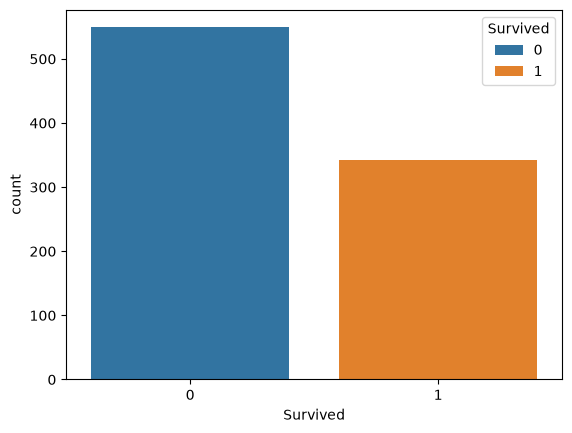

In [16]:
sns.countplot(data=train_data, x='Survived', hue='Survived');

### Анализ категориальных фичей

#### Фича Pclass

In [17]:
train_data['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

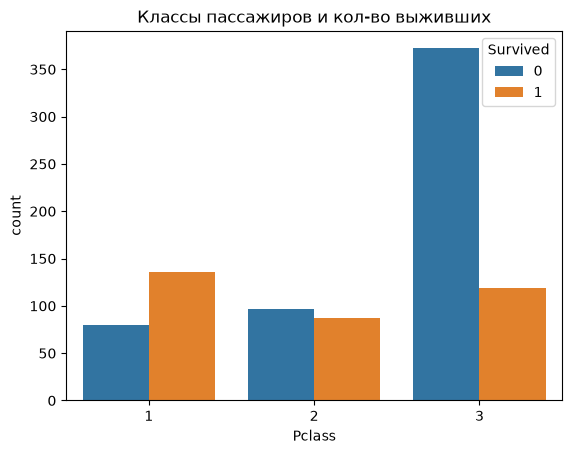

In [20]:
plt.title('Классы пассажиров и кол-во выживших')
sns.countplot(data=train_data, x='Pclass', hue='Survived');

In [21]:
train_data.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

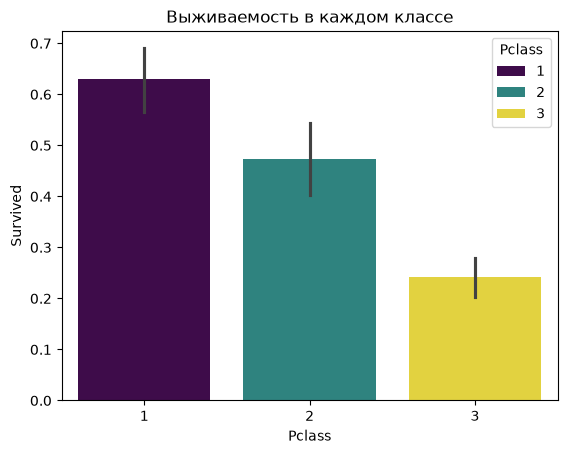

In [31]:
plt.title('Выживаемость в каждом классе')
sns.barplot(data=train_data, x='Pclass', y='Survived', hue='Pclass', palette='viridis');

Очевидно, что пассажиры из более хорошего класса выживали с большей вероятностью

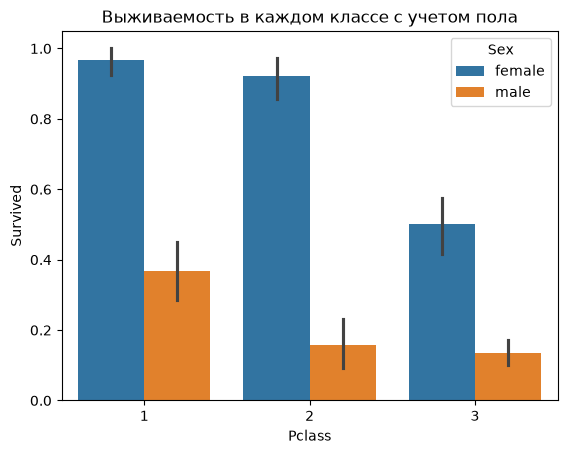

In [66]:
plt.title('Выживаемость в каждом классе c учетом пола')
sns.barplot(data=train_data, x='Pclass', y='Survived', hue='Sex');

Видим, что вне зависимости от класса женщины выживают чаще мужчин

#### Фича Sex

In [34]:
train_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [35]:
train_data.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Мужчин больше, но выживаемость лучше у женщин

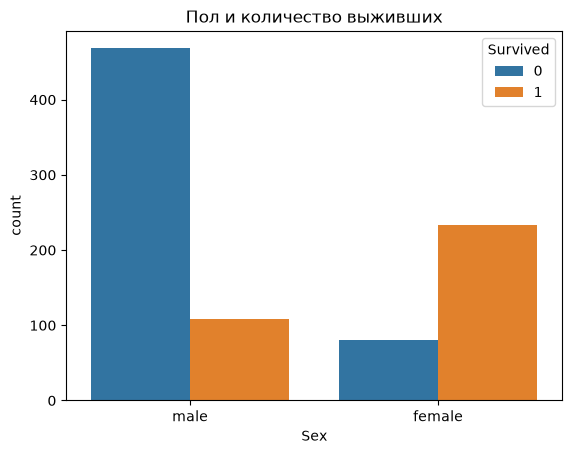

In [42]:
plt.title('Пол и количество выживших')
sns.countplot(data=train_data, x='Sex', hue='Survived');

#### Фича Embarked

In [44]:
train_data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

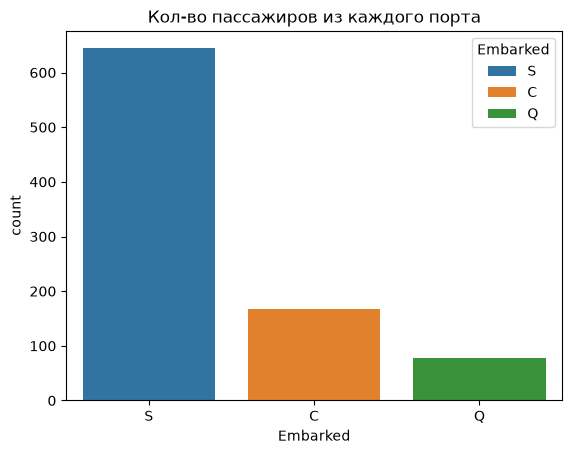

In [49]:
plt.title('Кол-во пассажиров из каждого порта')
sns.countplot(data=train_data, x='Embarked', hue='Embarked');

In [45]:
train_data.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

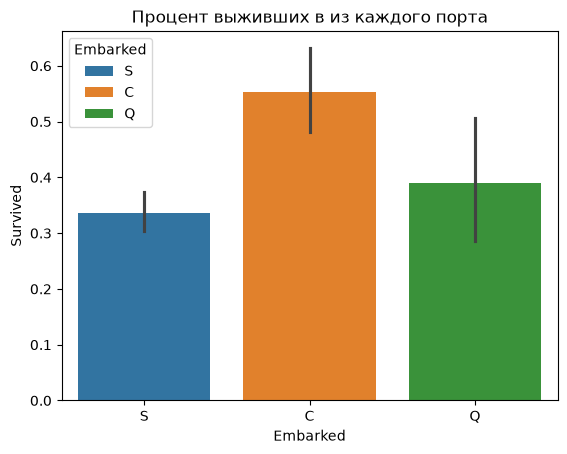

In [63]:
plt.title('Процент выживших в из каждого порта')
sns.barplot(data=train_data, x='Embarked', y='Survived', hue='Embarked');

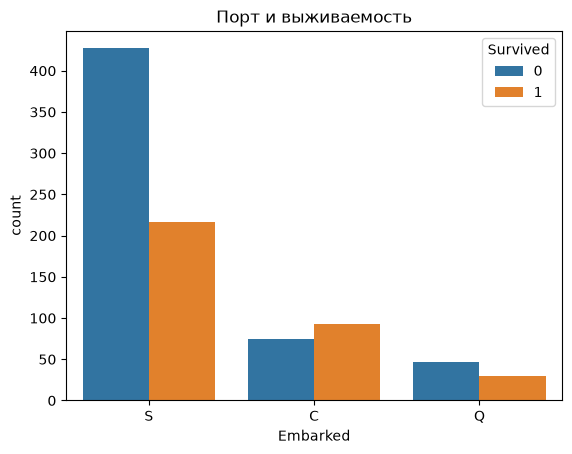

In [58]:
plt.title('Порт и выживаемость')
sns.countplot(data=train_data, x='Embarked', hue='Survived');

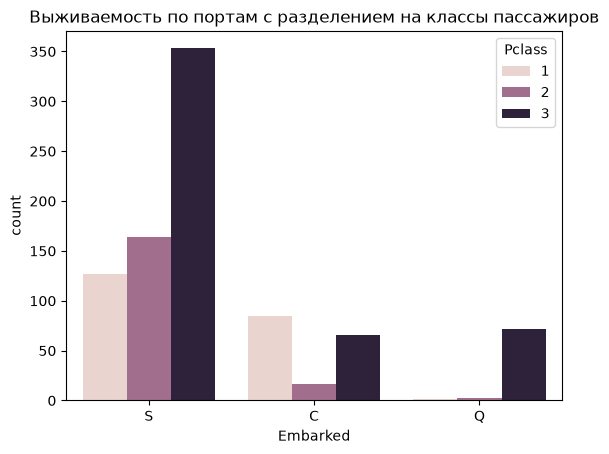

In [59]:
plt.title('Выживаемость по портам с разделением на классы пассажиров')
sns.countplot(data=train_data, x='Embarked', hue='Pclass');

In [68]:
train_data[train_data['Embarked'] == 'Q']['Pclass'].value_counts()

Pclass
3    72
2     3
1     2
Name: count, dtype: int64

Самый многочисленный по пассажирам порт - S, самое большое количесвто людей первого класса из этого порта, однако их доля там меньше относительно других классов  
В порту "C" самая большая доля пассажиров первого класса  
Порт Q самый бичарский и немногочисленный

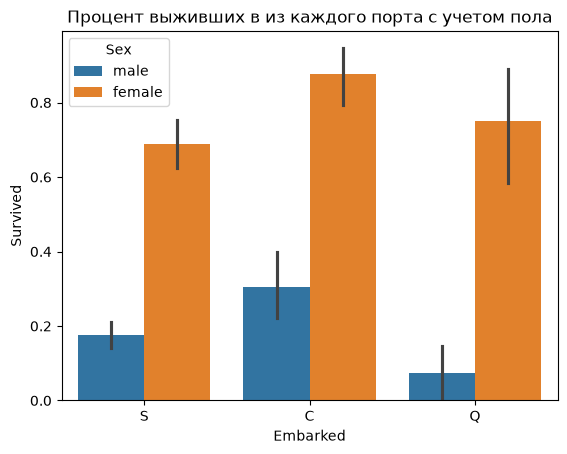

In [65]:
plt.title('Процент выживших в из каждого порта с учетом пола')
sns.barplot(data=train_data, x='Embarked', y='Survived', hue='Sex');

#### Фича SibSp

In [71]:
train_data['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

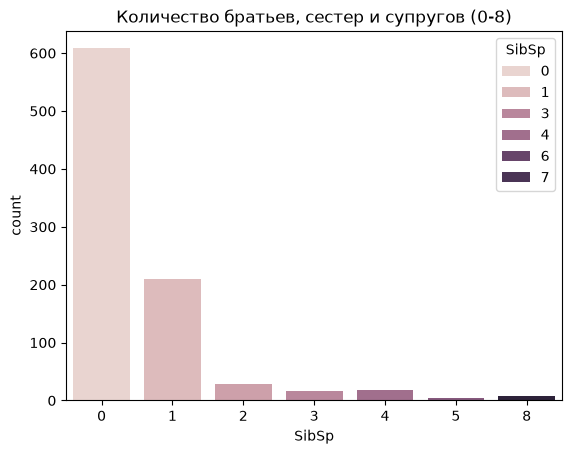

In [82]:
plt.title('Количество братьев, сестер и супругов (0-8)')
sns.countplot(data=train_data, x='SibSp', hue='SibSp');

In [75]:
train_data.groupby('SibSp')['Survived'].mean()

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

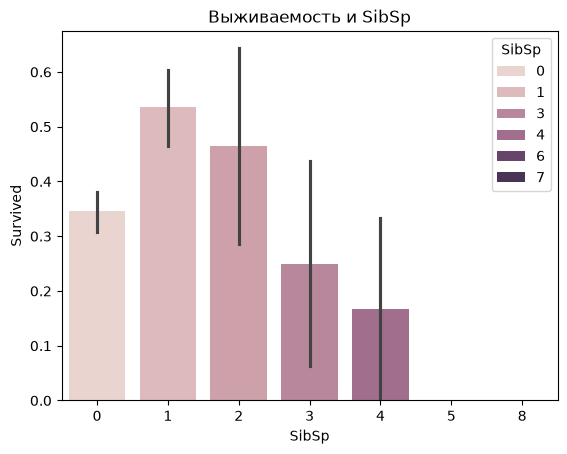

In [81]:
plt.title('Выживаемость и SibSp')
sns.barplot(data=train_data, x='SibSp', y='Survived', hue='SibSp');

In [91]:
table = pd.crosstab(
    [train_data['Pclass'], train_data['SibSp']],
    train_data['Survived'],
    margins=True
)
table.style.background_gradient(cmap='viridis')


Количество SibSp большее чем 3 встречается только в 3-ем классе, да и SibSp==2 или SibSp==3 в 1-ом и 2-ом классе единичные случаи

Иметь 1 или 2 SibSp в среднем выгоднее, чем 0, однако большее количество SibSp ведет к снижению шансов на выживание, плюс это пересекается с классом